In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

In [ ]:
model_name = "dynamo_old"
fadata = cafe.data.read_pancrease()
fadata.load_trajectory_dict(model_name_list=[model_name])
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         


[10/30/2025 12:28:40] DEBUG    extract 'clusters' from prior infomation as parameter 'color'                                                                                                            
                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    plot_trajectory                                                                                                                                                          


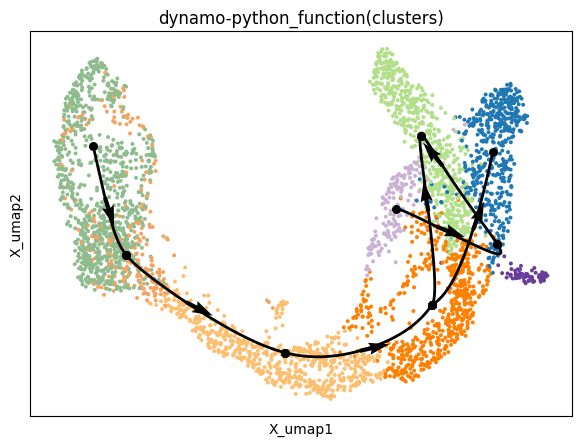

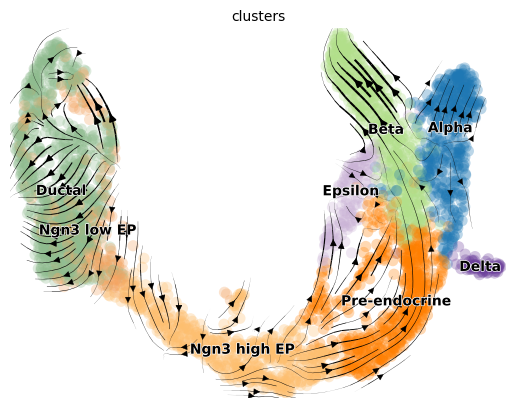

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
cafe.plot.plot_trajectory(fadata)
cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity")
fadata

直接输出原生dynamo可视化结果进行对比，说明方法dynamo内部执行，包括部预处理没有问题

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


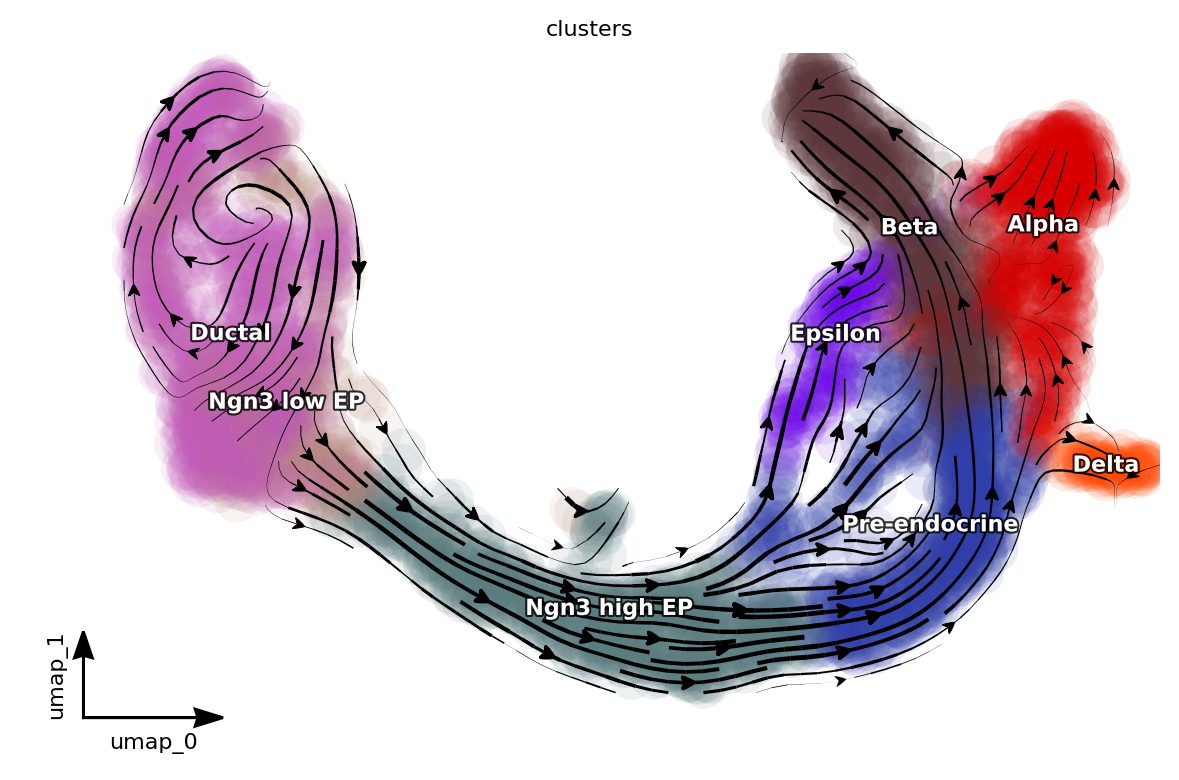

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index', 'counts_Size_Factor', 'nCounts', 'pMito', 'velocity_self_transition', 'spliced_Size_Factor', 'initial_counts_cell_size', 'Size_Factor', 'expression_Size_Factor', 'initial_expression_cell_size', 'initial_cell_size', 'initial_unspliced_cell_size', 'ntr', 'initial_spliced_cell_size', 'nGenes', 'unspliced_Size_Factor', 'pass_basic_filter'
    var: 'highly_variable_genes', 'nCounts', 'use_for_transition', 'log_m', 'use_for_dynamics', 'score', 'nCells', 'frac', 'ntr', 'log_cv', 'pass_basic_filter', 'use_for_pca'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename', 'dynamics', 'velocity_graph', 'velocyto_SVR', 'velocity_graph_neg', 'PCs', 'explained_variance_ratio_', 'grid_velocity_umap', 'vel_params_names', 'pp', 'feature_selection', 'pca_mean', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'


In [ ]:
# external_data = fadata.get_trajectory_dict(model_name=model_name)["raw_wrapper_dict"]["external_data"]
# 额外数据保存下来
import dynamo as dyn
adata = fadata.recovery_external_data(model_name=model_name)
dyn.pl.streamline_plot(adata, color=["clusters"], basis="umap", show_legend="on data", show_arrowed_spines=True)
adata

对比保存下来的低维速率，发现这里差不多，说明只是scvelo不擅长对于dynamo流行图结果的可视化，仅此而已。

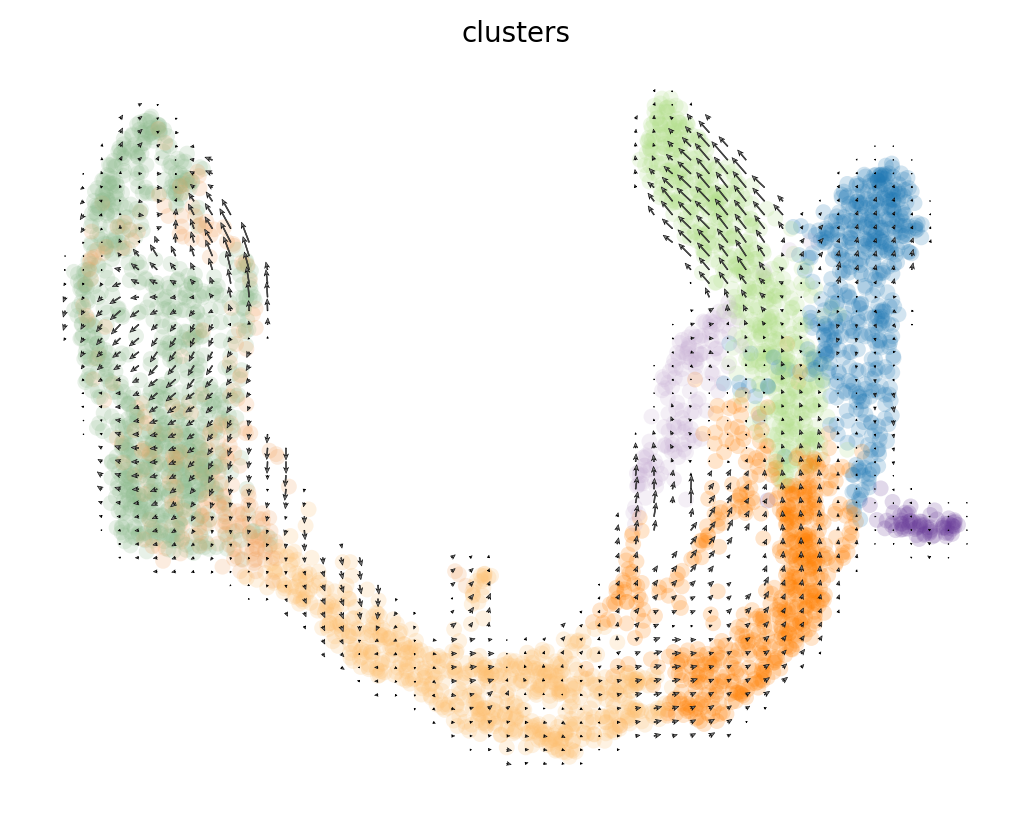

computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


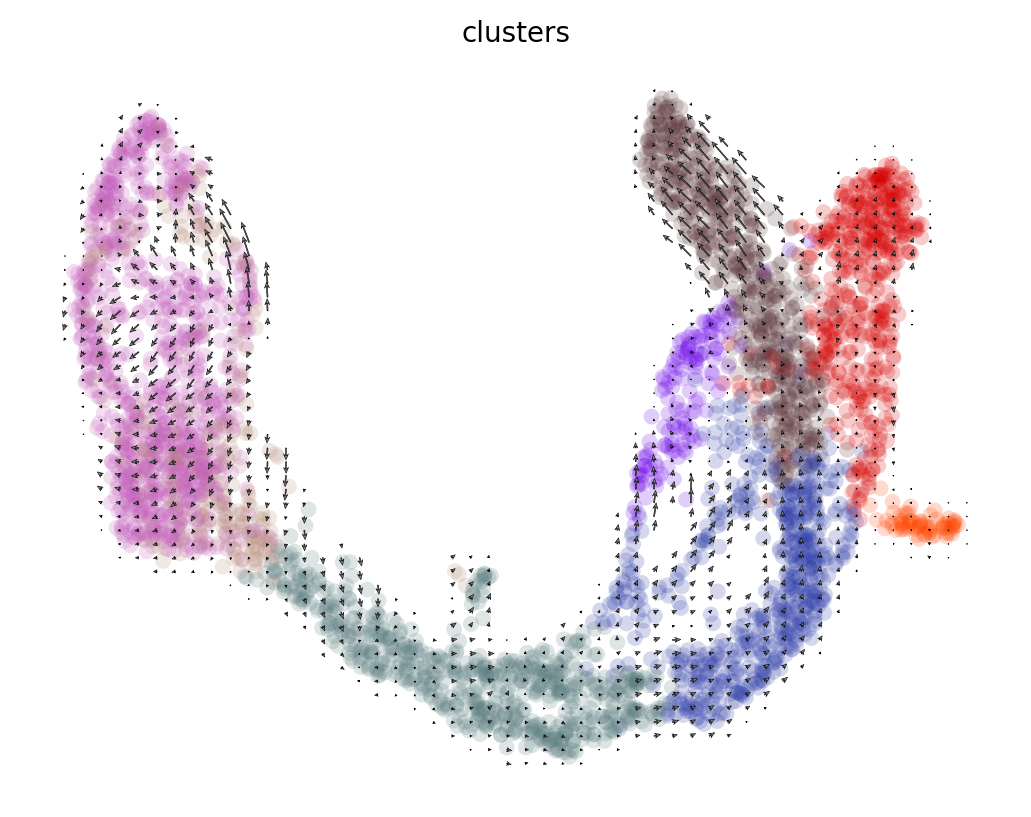

In [ ]:
import scvelo as scv
cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity", mode="grid")
scv.pl.velocity_embedding_grid(adata, basis="X_umap")

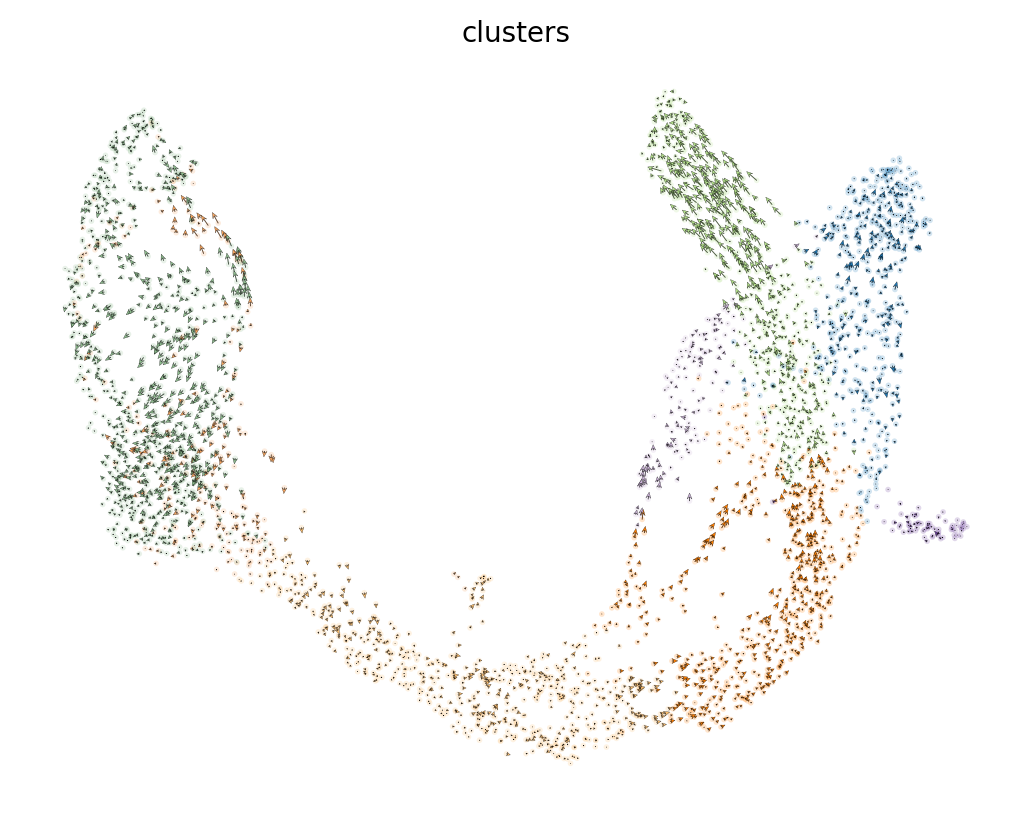

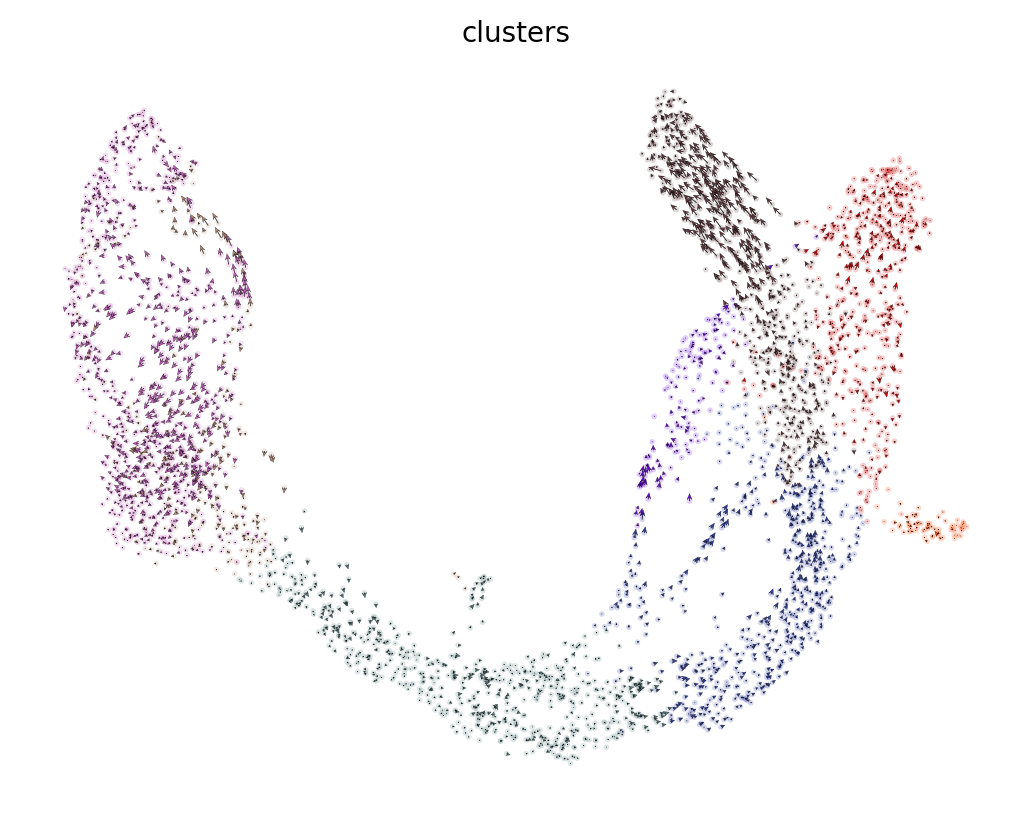

In [ ]:
cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity", mode="cell")
scv.pl.velocity_embedding(adata, basis="X_umap")

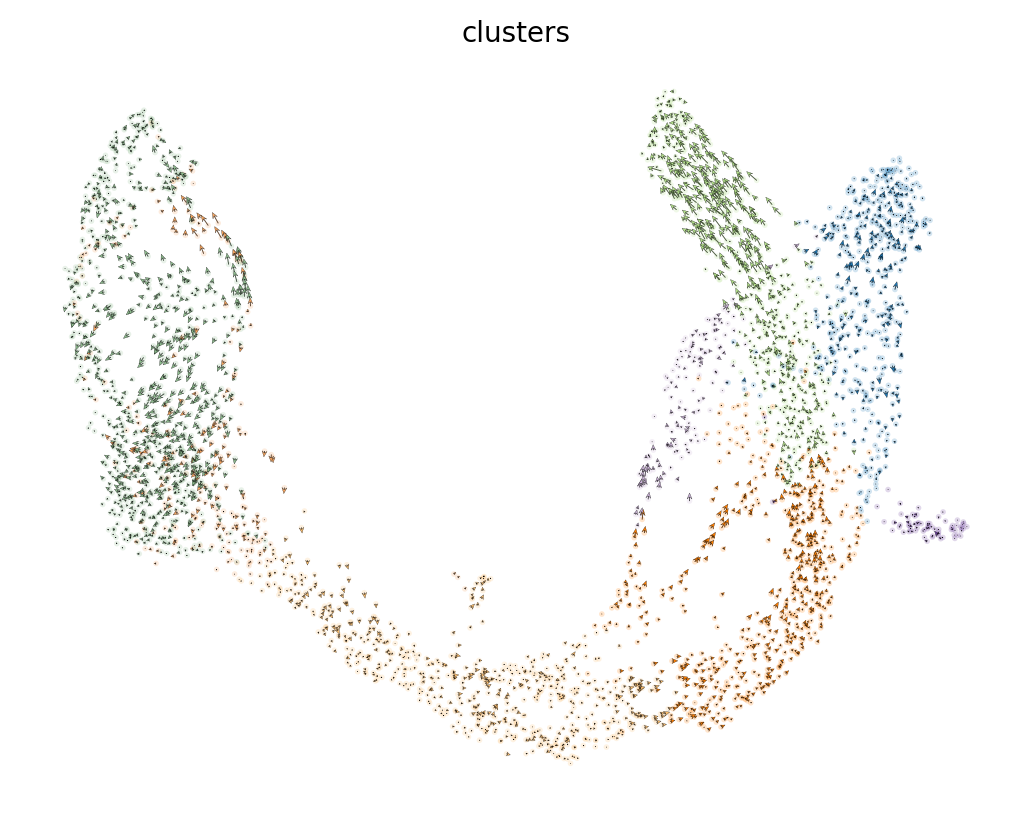

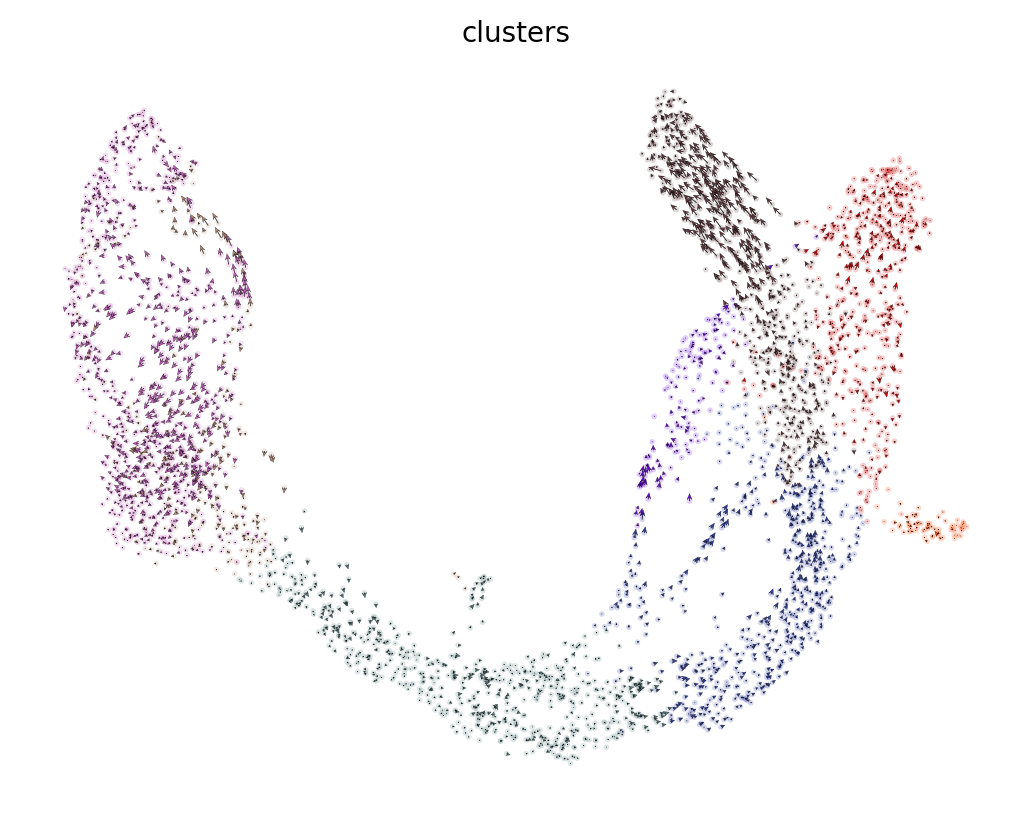

In [ ]:
cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity", mode="cell")
scv.pl.velocity_embedding(adata, basis="X_umap")

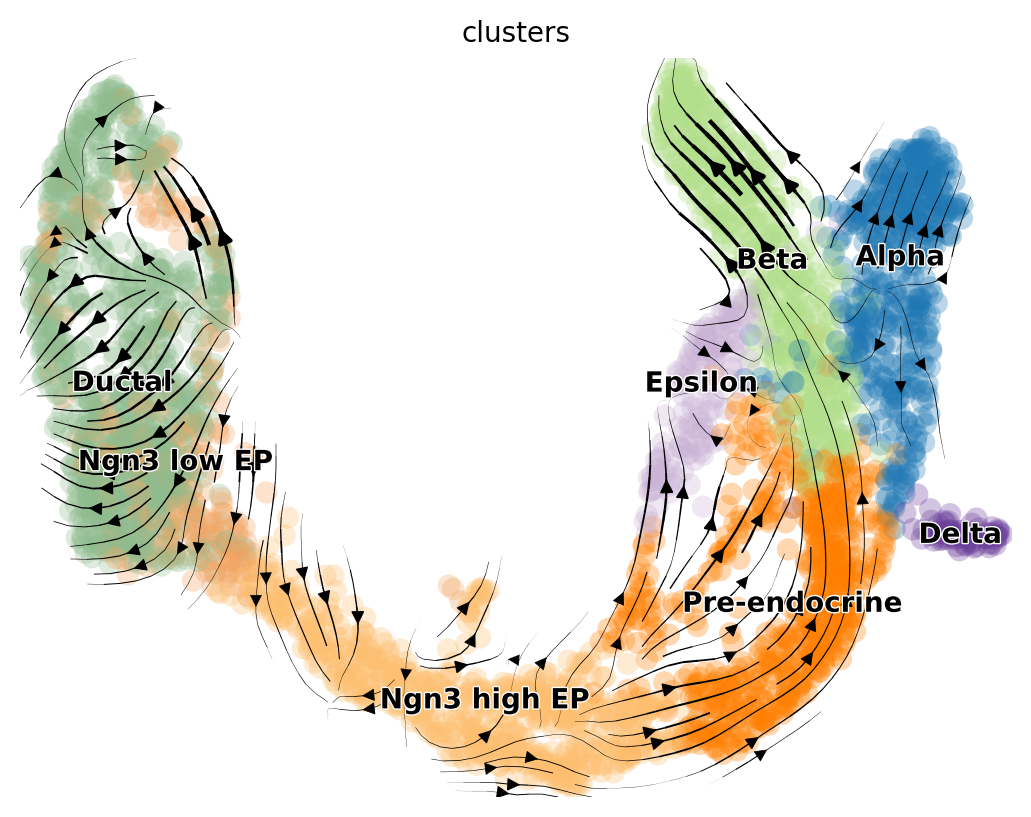

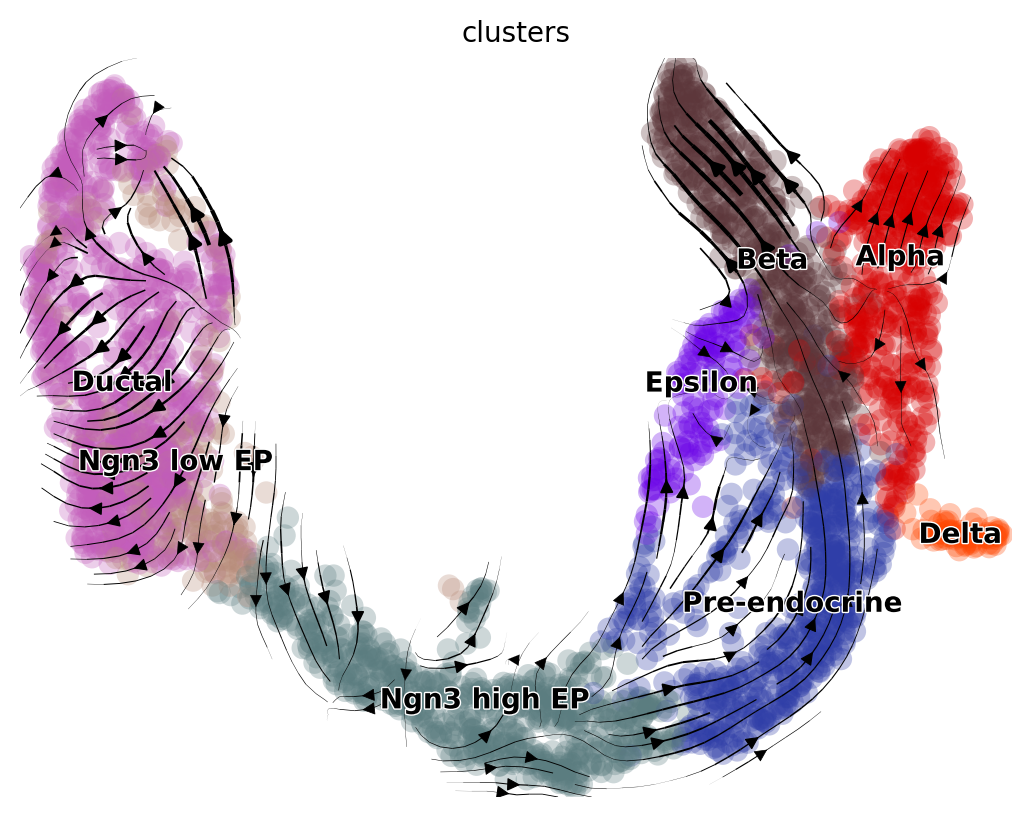

In [ ]:
cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity", mode="stream")
scv.pl.velocity_embedding_stream(adata, basis="X_umap")

可以借鉴这个优化参考：https://omicverse.readthedocs.io/en/latest/Tutorials-velo/t_graphvelo/#graphvelo-scvelo